Dataset Shape:
(2000, 31)

First 5 Rows:
            Time        V1        V2        V3        V4        V5        V6  \
0  167595.061255 -0.264799  0.602586 -1.057775 -1.412052  0.531687 -0.069467   
1   29776.873744 -0.187166  1.276264  0.371207  0.018231 -0.019530 -0.713629   
2  120120.978939  0.922181 -1.719689 -0.896341  0.908013  0.097451  0.211875   
3   82922.507189 -2.012349  1.877221  0.692500  0.102803 -0.891360 -0.438067   
4  116069.878265  0.882182  1.536463 -2.583519  0.595709  0.264251  1.027085   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0 -0.002911 -0.797647  0.391177  ... -1.361661 -0.085376 -0.843510  0.567228   
1 -0.543983  0.427376 -1.385361  ...  1.917288  0.829098 -0.741843 -0.381771   
2  0.711384 -0.889601  1.055073  ...  1.398592 -0.421531  1.067802 -0.546425   
3  0.609351  0.632079  0.668393  ... -1.118012 -0.313261  3.158942 -0.261469   
4 -1.125626 -0.506141  0.900537  ...  0.786330 -0.875503  0.704197 -1.608849  

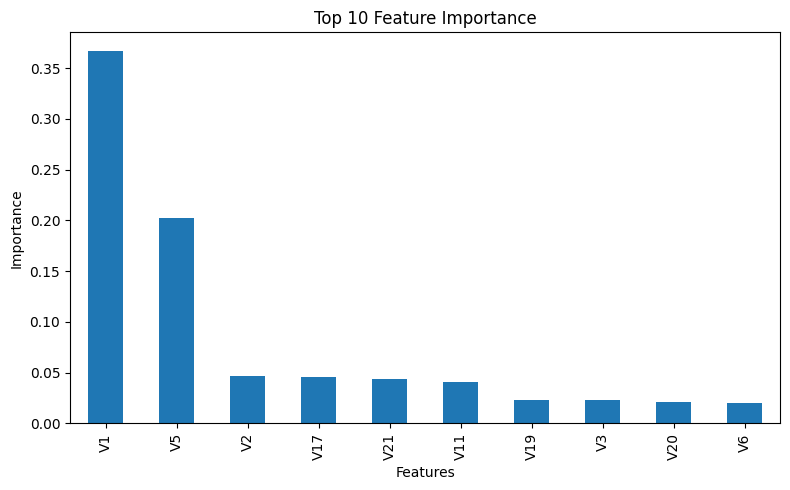

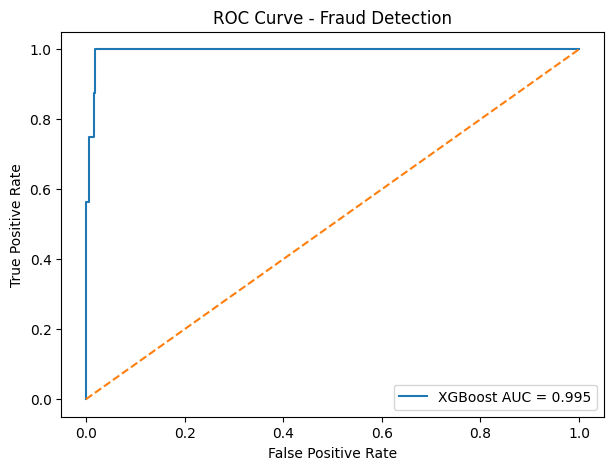


========== SVM Results ==========
              precision    recall  f1-score   support

           0       0.96      0.52      0.67       384
           1       0.04      0.44      0.07        16

    accuracy                           0.51       400
   macro avg       0.50      0.48      0.37       400
weighted avg       0.92      0.51      0.65       400

ROC-AUC: 0.5308

Confusion Matrix:
[[198 186]
 [  9   7]]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

df = pd.read_csv("creditcard.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nClass Distribution:")
print(df["Class"].value_counts())

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)


print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

y_prob = xgb.predict_proba(X_test)[:, 1]


y_pred = (y_prob >= 0.5).astype(int)


print("\n========== XGBoost Results ==========")

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob), 4)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

threshold = 0.3

y_pred_tuned = (y_prob >= threshold).astype(int)


print("\n========== XGBoost Threshold = 0.3 ==========")

print(classification_report(
    y_test,
    y_pred_tuned,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


print("\n========== Top 10 Important Features ==========")

print(importance.head(10))

importance.head(10).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost AUC = {roc_auc_score(y_test, y_prob):.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Fraud Detection")

plt.legend()

plt.show()

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(
    X_train_smote,
    y_train_smote
)

svm_prob = svm.predict_proba(X_test)[:, 1]

svm_pred = (svm_prob >= 0.5).astype(int)


print("\n========== SVM Results ==========")

print(classification_report(
    y_test,
    svm_pred,
    zero_division=0
))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, svm_prob), 4)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))